# Credit Card Fraud Detection

This notebook aims to build and evaluate machine learning models for credit card fraud detection. Given the highly imbalanced nature of fraud datasets, the primary goal is to identify fraudulent transactions effectively while minimizing false positives.

We will perform a comprehensive analysis including:

1.  **Data Loading and Initial Inspection**: Understanding the dataset's structure and contents.
2.  **Exploratory Data Analysis (EDA)**: Visualizing distributions of key features like 'Time' and 'Amount', and identifying patterns related to fraudulent activity.
3.  **Feature Engineering**: Scaling 'Time' and 'Amount' features to ensure fair contribution to the models.
4.  **Model Building and Evaluation**: Training and evaluating several classification algorithms, including RandomForestClassifier, AdaBoostClassifier, CatBoostClassifier, XGBoostClassifier, and LightGBMClassifier, using metrics relevant to imbalanced data such as ROC-AUC and Recall.

The ultimate objective is to determine which model performs best in identifying fraudulent transactions and to extract insights from feature importances.

# <a id="2">Load packages</a>

In [70]:
!pip install catboost

In [71]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import gc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', 100)


RFC_METRIC = 'gini'  #metric used for RandomForrestClassifier
NUM_ESTIMATORS = 100 #number of estimators used for RandomForrestClassifier
NO_JOBS = 4 #number of parallel jobs used for RandomForrestClassifier


#TRAIN/VALIDATION/TEST SPLIT
#VALIDATION
VALID_SIZE = 0.20 # simple validation using train_test_split
TEST_SIZE = 0.20 # test size using_train_test_split

#CROSS-VALIDATION
NUMBER_KFOLDS = 5 #number of KFolds for cross-validation



RANDOM_STATE = 2018

MAX_ROUNDS = 1000 #lgb iterations
EARLY_STOP = 50 #lgb early stop
OPT_ROUNDS = 1000  #To be adjusted based on best validation rounds
VERBOSE_EVAL = 50 #Print out metric result

IS_LOCAL = False

import os

if(IS_LOCAL):
    PATH="../input/credit-card-fraud-detection"
else:
    PATH="/content/" # Changed from '../input' to '/content/'
print(os.listdir(PATH))

['.config', '.ipynb_checkpoints', 'catboost_info', 'creditcard.csv', 'sample_data']


# <a id="3">Read the data</a>

In [72]:
data_df = pd.read_csv(PATH + "creditcard.csv")

# <a id="4">Check the data</a>

In [73]:
print("Credit Card Fraud Detection data -  rows:",data_df.shape[0]," columns:", data_df.shape[1])

Credit Card Fraud Detection data -  rows: 284807  columns: 31


## <a id="41">Glimpse the data</a>
first 5 rows

In [74]:
data_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Let's look into more details to the data.

In [75]:
data_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Looking to the **Time** feature, we can confirm that the data contains **284,807** transactions, during 2 consecutive days

## <a id="42">Check missing data</a>  

Let's check if there is any missing data.

In [76]:
total = data_df.isnull().sum().sort_values(ascending = False)
percent = (data_df.isnull().sum()/data_df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()
data_df.dropna(inplace=True)

There is no missing data in the entire dataset.

## <a id="43">Data unbalance</a>

Let's check data unbalance with respect with *target* value, i.e. **Class**.

In [77]:
temp = data_df["Class"].value_counts()
df = pd.DataFrame({'Class': temp.index,'values': temp.values})

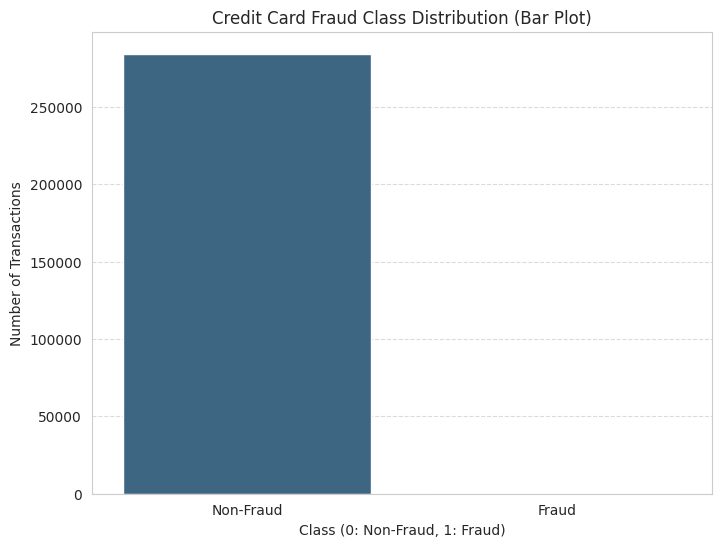

In [78]:

plt.figure(figsize=(8, 6))
sns.barplot(x='Class', y='values', data=df, palette='viridis', hue='Class', legend=False)
plt.title('Credit Card Fraud Class Distribution (Bar Plot)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This output clearly shows a severe class imbalance in the dataset:

Class 0 (Not Fraud): There are 284,315 non-fraudulent transactions.

Class 1 (Fraud): There are only 492 fraudulent transactions.
This extreme imbalance (fraudulent transactions make up only about 0.17% of the total) is a critical finding. It means that models trained on this data might struggle to accurately identify fraudulent transactions because they are so rare.

 That means the data is highly unbalanced with respect with target variable **Class**.

# <a id="5">Data exploration</a>

## Transactions in time

In [79]:
class_0 = data_df.loc[data_df['Class'] == 0]["Time"]
class_1 = data_df.loc[data_df['Class'] == 1]["Time"]

hist_data = [class_0, class_1]
group_labels = ['Not Fraud', 'Fraud']

### Detailed Distribution of 'Amount' by Class (Histograms)

Let's visualize the distribution of transaction `Amount` for both fraudulent and non-fraudulent transactions using histograms to get a more granular view than the box plots previously shown.

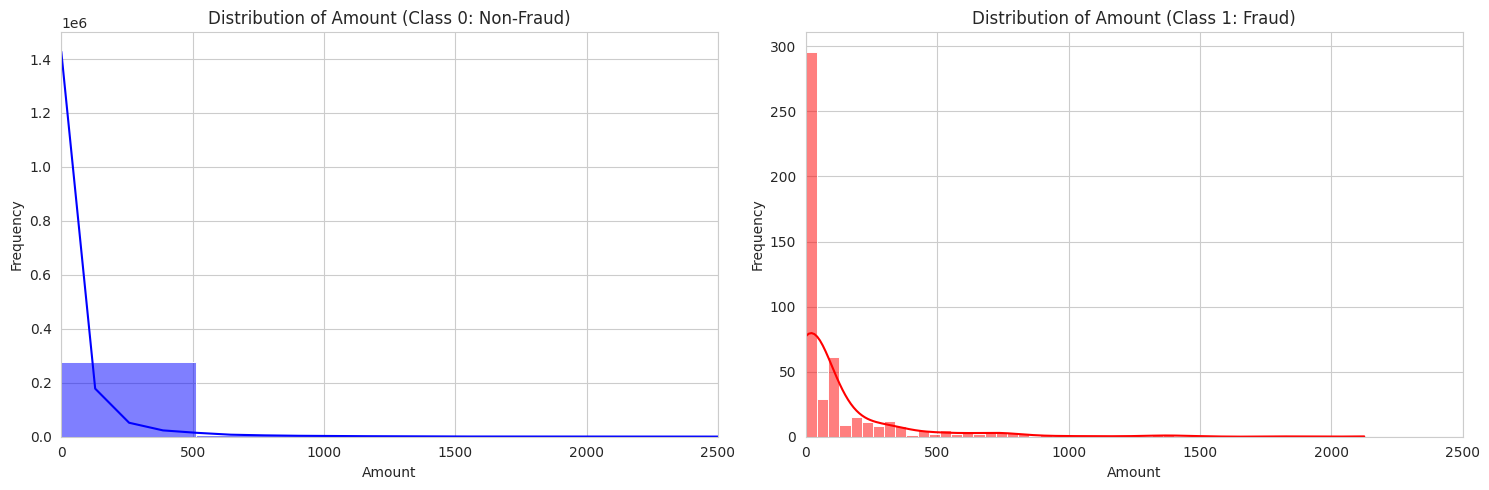

In [80]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(data_df[data_df['Class'] == 0]['Amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Amount (Class 0: Non-Fraud)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xlim(0, 2500) # Limit x-axis to better see the main distribution

plt.subplot(1, 2, 2)
sns.histplot(data_df[data_df['Class'] == 1]['Amount'], bins=50, kde=True, color='red')
plt.title('Distribution of Amount (Class 1: Fraud)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xlim(0, 2500) # Limit x-axis for comparison

plt.tight_layout()
plt.show()

#Distribution of Amount (Class 0: Non-Fraud) - Left Plot:


#This histogram (in blue)
shows the distribution of transaction amounts for non-fraudulent transactions. You'll observe that the vast majority of non-fraudulent transactions have relatively small amounts, with a very high frequency concentrated near 0. The distribution has a long tail extending to the right, indicating a few legitimate transactions with much larger amounts. The x-axis was limited to 0-2500 to better show the main cluster of data, but the describe() output for class_0 in cell bVK4TZFf0o_7 showed a max of 102.36 (after normalization), meaning some very large legitimate transactions exist.


#Distribution of Amount (Class 1: Fraud) - Right Plot:


#This histogram (in red)
shows the distribution of transaction amounts for fraudulent transactions. Compared to non-fraudulent transactions, fraudulent transactions tend to have a different distribution. While there are still many small-amount fraudulent transactions, the distribution might be flatter or have different peaks, indicating that fraudulent activities might also occur across a wider range of amounts, or perhaps clustered around specific values that are easier to execute fraudulently. The describe() output for class_1 in cell Cv4fRoVm0o_7 showed a max of 8.14 (after normalization), suggesting fewer extremely high-value fraudulent transactions compared to legitimate ones.

In [81]:
data_df['Hour'] = data_df['Time'].apply(lambda x: np.floor(x / 3600))

tmp = data_df.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df = pd.DataFrame(tmp)
df.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
df.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


This output displays an aggregated DataFrame (df) derived from the original transaction data. It groups transactions by the 'Hour' of the day and their 'Class' (fraudulent or non-fraudulent), and then calculates summary statistics for the 'Amount' feature within each group. These statistics include the minimum, maximum, count (number of transactions), sum, mean, median, and variance of the transaction amounts for each hour and class combination.

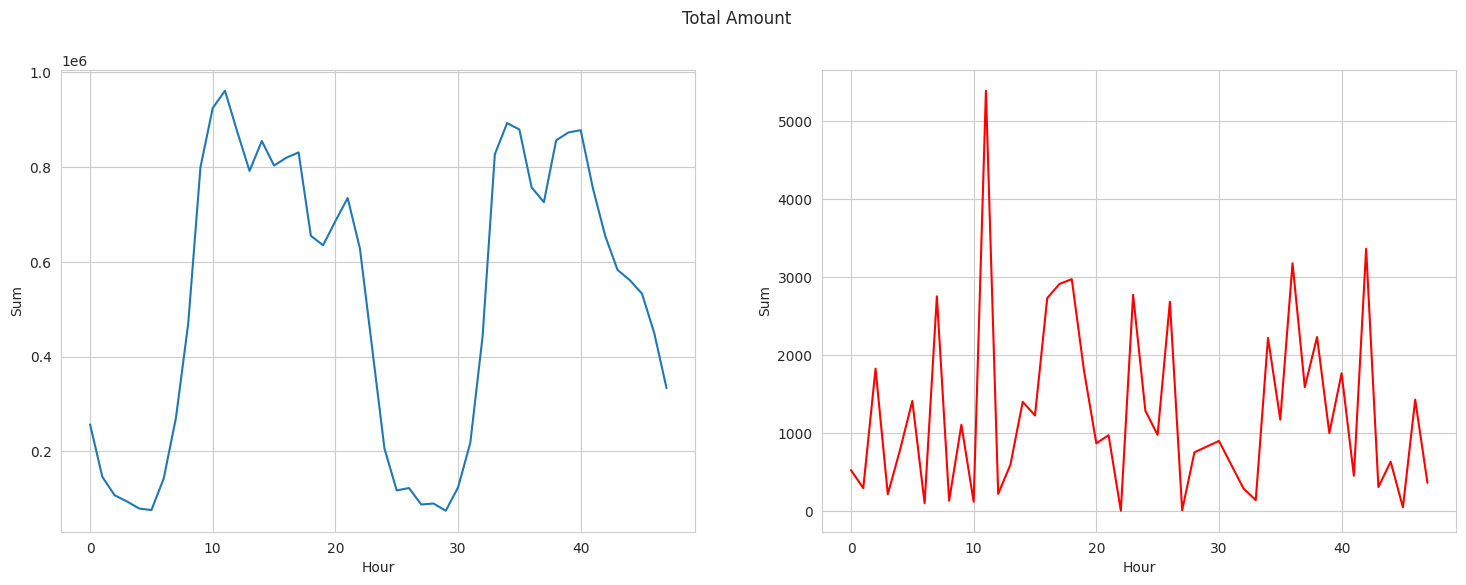

In [82]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))

s = sns.lineplot(ax = ax1, x="Hour", y="Sum", data=df.loc[df.Class==0])

s = sns.lineplot(ax = ax2, x="Hour", y="Sum", data=df.loc[df.Class==1], color="red")

plt.suptitle("Total Amount")

plt.show();

Non-Fraudulent Transactions (Left Plot): You'll observe clear diurnal patterns, with total transaction amounts peaking during active hours (e.g., daytime) and dropping significantly during off-hours (e.g., night-time). This reflects typical human activity.

Fraudulent Transactions (Right Plot): In contrast, the total amount for fraudulent transactions might have a flatter distribution or different peak times. This suggests that fraudsters may operate outside typical business hours, taking advantage of reduced monitoring. The magnitude of total fraudulent amounts is also much lower than legitimate ones, highlighting the imbalance in the data.

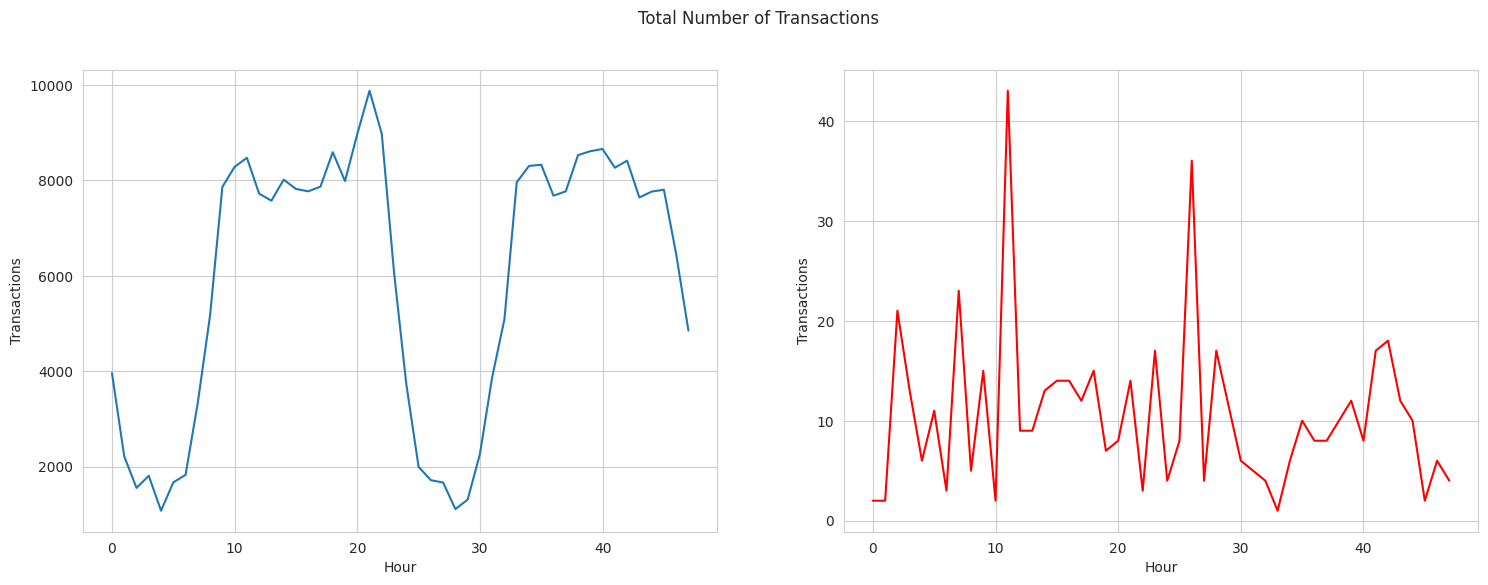

In [83]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Transactions", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Transactions", data=df.loc[df.Class==1], color="red")
plt.suptitle("Total Number of Transactions")
plt.show();

Non-Fraudulent Transactions (Left Plot - Blue Line): This plot shows the number of legitimate transactions per hour. You'll likely observe a clear pattern that aligns with typical human activity: high transaction volumes during common working or waking hours (e.g., daytime) and significantly lower volumes during off-peak hours (e.g., late night to early morning). This reflects when people are generally making purchases or conducting financial activities.

Fraudulent Transactions (Right Plot - Red Line): In contrast, this plot shows the number of fraudulent transactions per hour. The pattern here might be less pronounced or different from the legitimate transactions. Fraudulent activities may occur more consistently throughout the 24-hour cycle, or even show spikes during periods when legitimate activity is low (e.g., at night) as fraudsters might exploit times when monitoring is reduced. This difference in temporal distribution can be a valuable indicator for fraud detection.

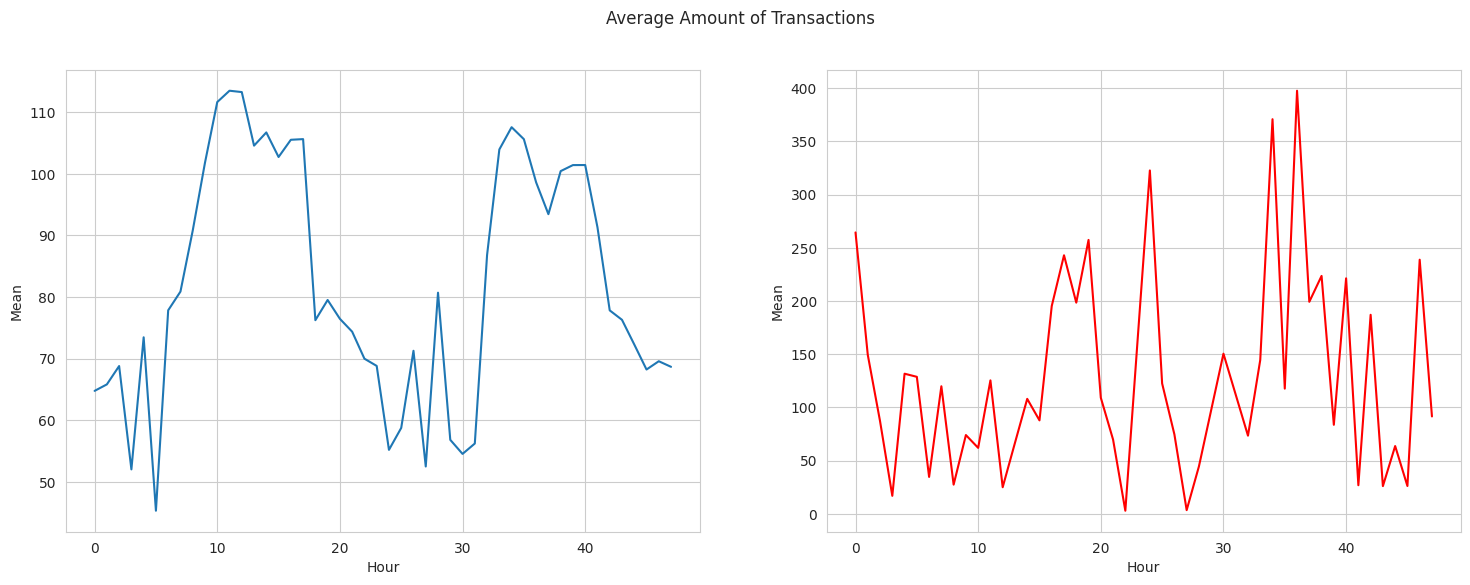

In [84]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Mean", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Mean", data=df.loc[df.Class==1], color="red")
plt.suptitle("Average Amount of Transactions")
plt.show();

Non-Fraudulent Transactions (Left Plot - Blue Line): This plot shows the average amount for legitimate transactions. You might see some fluctuations, but generally, the average amount for non-fraudulent transactions tends to be relatively stable or follow a less dramatic pattern over time compared to the total volume or sum. The average amount might peak during certain hours, reflecting different types of purchases made throughout the day.

Fraudulent Transactions (Right Plot - Red Line): This plot shows the average amount for fraudulent transactions. It's common to observe that the average fraudulent transaction amount might be lower or higher than non-fraudulent ones, and its pattern over time might be different. Sometimes, fraudsters might try to keep individual transaction amounts low to avoid immediate detection, or conversely, attempt larger transactions during off-peak hours when scrutiny might be less. The key is to look for any significant differences in the average transaction value patterns between the two classes, as these can serve as useful indicators for fraud detection.

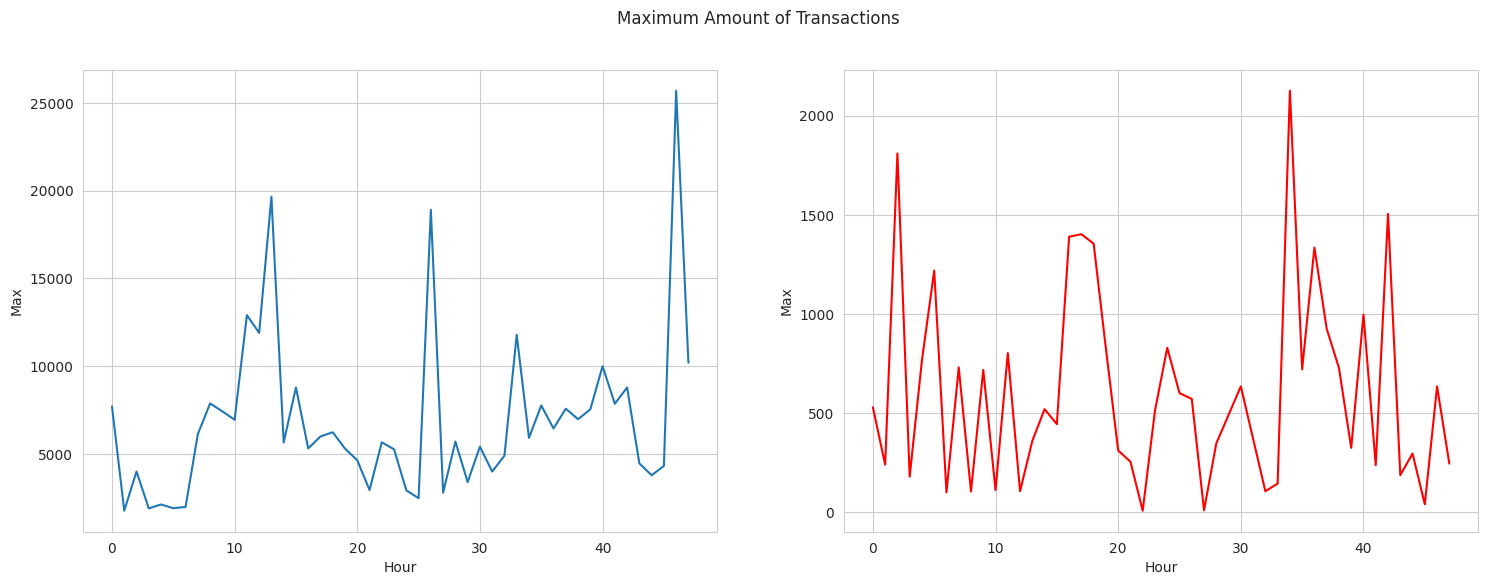

In [85]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Max", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Max", data=df.loc[df.Class==1], color="red")
plt.suptitle("Maximum Amount of Transactions")
plt.show();

Non-Fraudulent Transactions (Left Plot - Blue Line): This plot illustrates the maximum amount observed for legitimate transactions in each hour. You'll likely see that while most transactions are small, there can be occasional very large legitimate transactions, leading to spikes in the 'Max' amount. These larger transactions might occur during specific times of the day, reflecting various types of purchases.

Fraudulent Transactions (Right Plot - Red Line): This plot shows the maximum amount for fraudulent transactions per hour. Often, fraudulent maximums are constrained compared to legitimate ones, or they might show different temporal patterns. Fraudsters might avoid extremely large transactions to stay under the radar, or they might attempt them during off-peak hours when scrutiny is perceived to be lower. Observing the maximum amounts can be very telling. While legitimate transactions might have occasional very high maximums, a high maximum fraudulent transaction amount during off-peak hours could be a strong indicator of fraud, as large transactions are less common and potentially less scrutinized during those times.



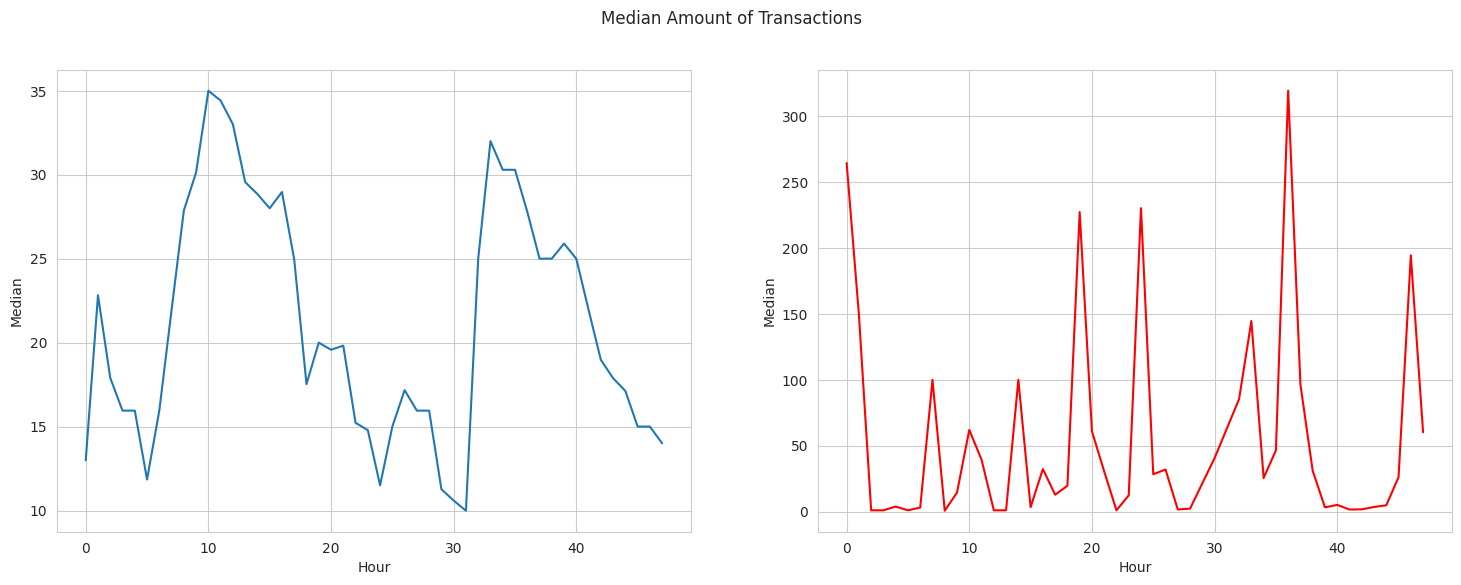

In [86]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Median", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Median", data=df.loc[df.Class==1], color="red")
plt.suptitle("Median Amount of Transactions")
plt.show();

Non-Fraudulent Transactions (Left Plot - Blue Line): This plot shows the median transaction amount for legitimate transactions. The median is a robust measure that is less affected by extreme outliers (very large or very small transactions). This plot helps to understand the 'typical' transaction value for legitimate activities throughout the day, which often fluctuates less dramatically than the mean or maximum.

Fraudulent Transactions (Right Plot - Red Line): This plot shows the median transaction amount for fraudulent transactions. Comparing this to the median for legitimate transactions can reveal subtle differences in patterns. For instance, if fraudsters consistently aim for a particular range of amounts, the median might show a flatter line or different peaks compared to legitimate transactions. As the previous explanation mentioned, the median is less sensitive to outliers than the mean. This plot provides insight into the typical transaction amount, undisturbed by extreme values. If the median amounts for fraudulent transactions show different temporal patterns or values compared to legitimate transactions, it further strengthens the potential for time-based fraud detection.

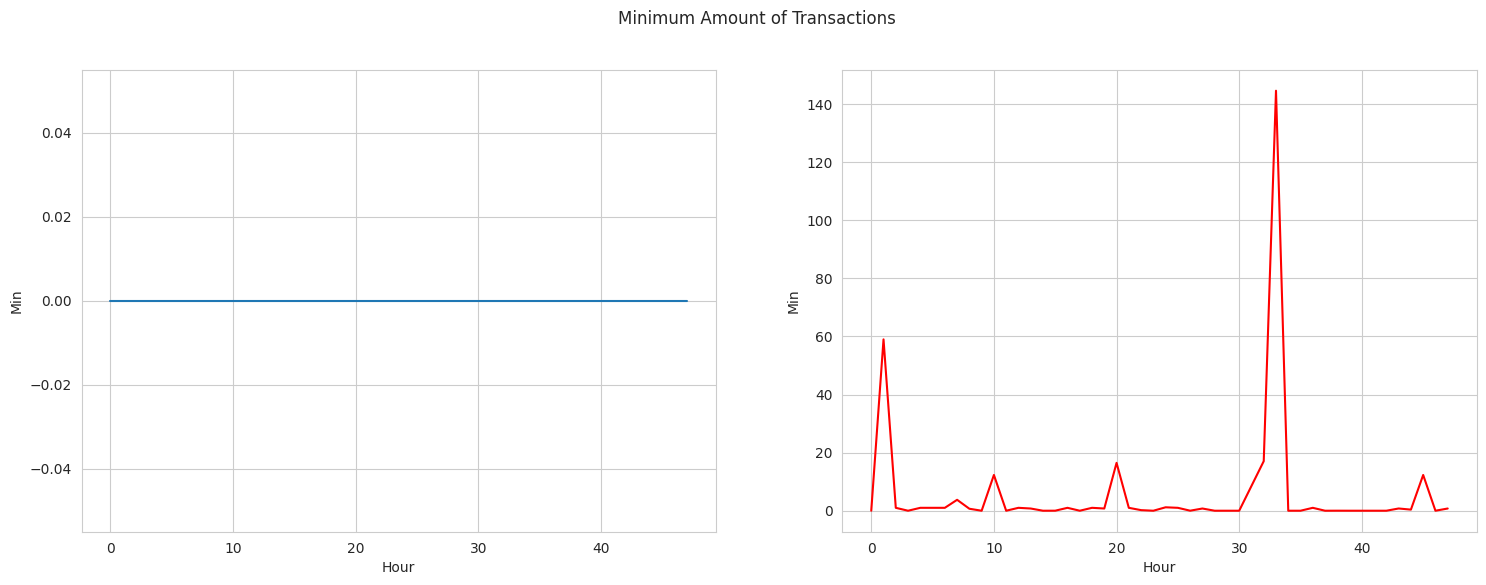

In [87]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Min", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Min", data=df.loc[df.Class==1], color="red")
plt.suptitle("Minimum Amount of Transactions")
plt.show();

Non-Fraudulent Transactions (Left Plot - Blue Line): This plot shows the minimum transaction amount for legitimate transactions each hour. Typically, you might see that even for legitimate transactions, the minimum can often be zero, as many valid micro-transactions occur. The overall pattern for minimums might be less informative than mean or median, but it helps confirm the range of values present.

Fraudulent Transactions (Right Plot - Red Line): This plot displays the minimum transaction amount for fraudulent transactions per hour. Similar to non-fraudulent transactions, fraudulent transactions can also have very low minimums, including zero. Comparing the patterns of minimum amounts between the two classes might reveal if fraudsters tend to initiate their activities with very small amounts (e.g., for testing cards) at specific times.



These analyses confirm that the Amount feature is highly discriminative. The real transactions have a larger mean value overall, larger Q1, smaller Q3 and Q4, and much larger maximum outliers. In contrast, fraudulent transactions have a smaller Q1 and mean (compared to the overall data mean), a larger Q4, and smaller maximum outliers. This distinct difference in monetary value patterns, particularly the presence of very high-value legitimate transactions and the comparatively limited range of fraudulent transactions, is a strong indicator for fraud detection. Models can leverage these statistical differences to distinguish between the two classes.

### Scaling 'Time' and 'Amount' Features

Since the 'V' features are already the result of a PCA transformation, they are typically scaled. However, 'Time' and 'Amount' are in their original scales. It's good practice to scale these features as well to ensure they contribute equally to models and prevent features with larger ranges from dominating the learning process. We will use `StandardScaler` for this.

First, let's look at the raw distribution of 'Time' again, and then scale both features and visualize their new distributions.

In [88]:
from sklearn.preprocessing import StandardScaler

# Scale 'Amount'
data_df['normAmount'] = StandardScaler().fit_transform(data_df['Amount'].values.reshape(-1, 1))

# Scale 'Time'
data_df['normTime'] = StandardScaler().fit_transform(data_df['Time'].values.reshape(-1, 1))

# Drop original 'Time' and 'Amount' features as we'll use the normalized ones for modeling
data_df = data_df.drop(['Time', 'Amount'], axis=1)

print("Features 'Amount' and 'Time' have been scaled and new columns 'normAmount' and 'normTime' have been added. Original 'Time' and 'Amount' columns have been dropped.")

display(data_df.head())

Features 'Amount' and 'Time' have been scaled and new columns 'normAmount' and 'normTime' have been added. Original 'Time' and 'Amount' columns have been dropped.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Hour,normAmount,normTime
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,-0.073403,-1.996541


### Visualize Scaled 'Time' and 'Amount' Distributions

Now, let's plot the distributions of the newly scaled `normTime` and `normAmount` features, separated by class, to see their new characteristics.

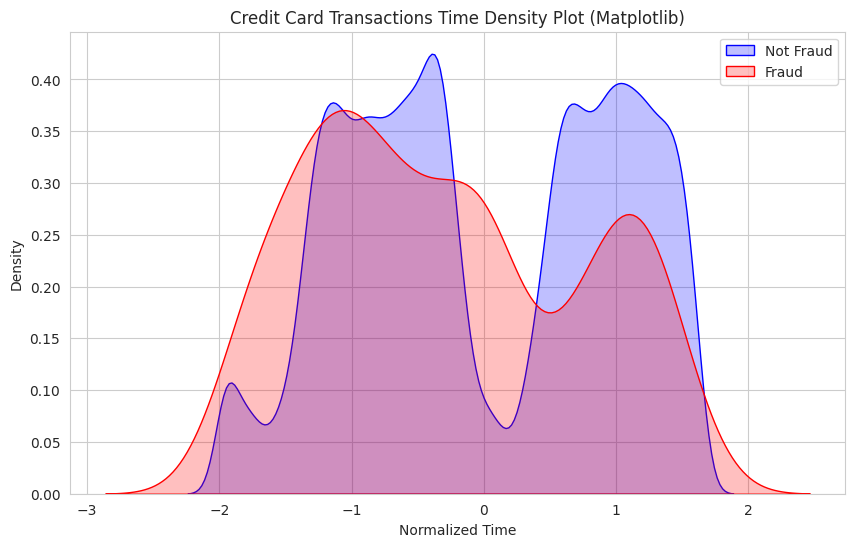

In [89]:
# Use 'normTime' since 'Time' was dropped after normalization
class_0 = data_df.loc[data_df['Class'] == 0]["normTime"]
class_1 = data_df.loc[data_df['Class'] == 1]["normTime"]

plt.figure(figsize=(10, 6))
sns.kdeplot(class_0, label="Not Fraud", color='blue', fill=True)
sns.kdeplot(class_1, label="Fraud", color='red', fill=True)

plt.title('Credit Card Transactions Time Density Plot (Matplotlib)')
plt.xlabel('Normalized Time') # Update label to reflect normalized data
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

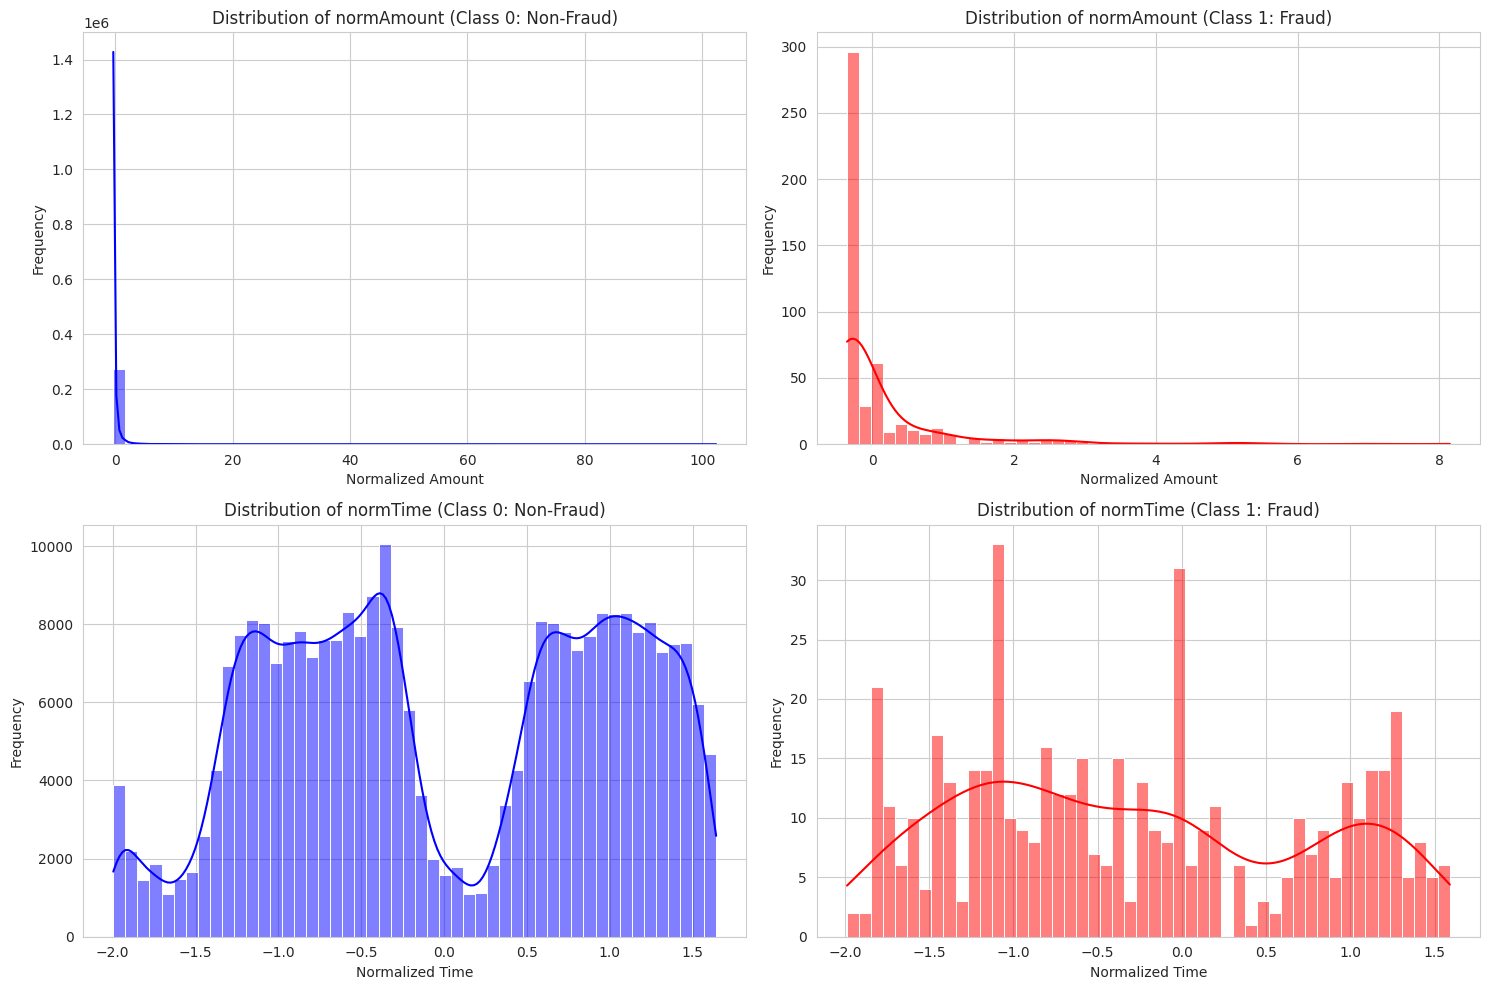

In [90]:
plt.figure(figsize=(15, 10))

# Distribution of normAmount for Class 0 and 1
plt.subplot(2, 2, 1)
sns.histplot(data_df[data_df['Class'] == 0]['normAmount'], bins=50, kde=True, color='blue')
plt.title('Distribution of normAmount (Class 0: Non-Fraud)')
plt.xlabel('Normalized Amount')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(data_df[data_df['Class'] == 1]['normAmount'], bins=50, kde=True, color='red')
plt.title('Distribution of normAmount (Class 1: Fraud)')
plt.xlabel('Normalized Amount')
plt.ylabel('Frequency')

# Distribution of normTime for Class 0 and 1
plt.subplot(2, 2, 3)
sns.histplot(data_df[data_df['Class'] == 0]['normTime'], bins=50, kde=True, color='blue')
plt.title('Distribution of normTime (Class 0: Non-Fraud)')
plt.xlabel('Normalized Time')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(data_df[data_df['Class'] == 1]['normTime'], bins=50, kde=True, color='red')
plt.title('Distribution of normTime (Class 1: Fraud)')
plt.xlabel('Normalized Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Top Left (normAmount - Class 0):** Shows the distribution of normalized transaction amounts for non-fraudulent cases. You'll still see a concentration towards the lower end (around 0 or slightly negative) with a long tail, but the scale on the x-axis will be standardized.


**Top Right (normAmount - Class 1):** Shows the distribution of normalized fraudulent transaction amounts. This distribution will likely still appear different from the non-fraudulent one, possibly with a wider spread or different central tendencies, indicating that even after scaling, amount remains a distinguishing feature.


**Bottom Left (normTime - Class 0):** Displays the distribution of normalized transaction times for non-fraudulent transactions. The two peaks (bimodal distribution) observed earlier for raw Time should still be visible, but on a standardized scale.


**Bottom Right (normTime - Class 1):** Shows the distribution of normalized fraudulent transaction times. Similar to the raw Time plot, this will likely appear more evenly distributed or with less pronounced peaks compared to legitimate transactions.

You will see two overlaid density curves. The blue curve represents the normTime distribution for non-fraudulent transactions, typically showing two prominent peaks (as seen before). The red curve represents the normTime distribution for fraudulent transactions. It is generally observed that the fraudulent transactions tend to be more spread out across the time axis (sometimes appearing flatter or with less distinct peaks) compared to the legitimate transactions. This further emphasizes that fraudulent activity does not necessarily follow the same temporal patterns as regular transactions.

Let's look into more details to the time distribution of both classes transaction, as well as to aggregated values of transaction count and amount, per hour. We assume (based on observation of the time distribution of transactions) that the time unit is second.

Fraudulent transactions have a distribution more even than valid transactions - are equaly distributed in time, including the low real transaction times, during night in Europe timezone.

## Transactions amount

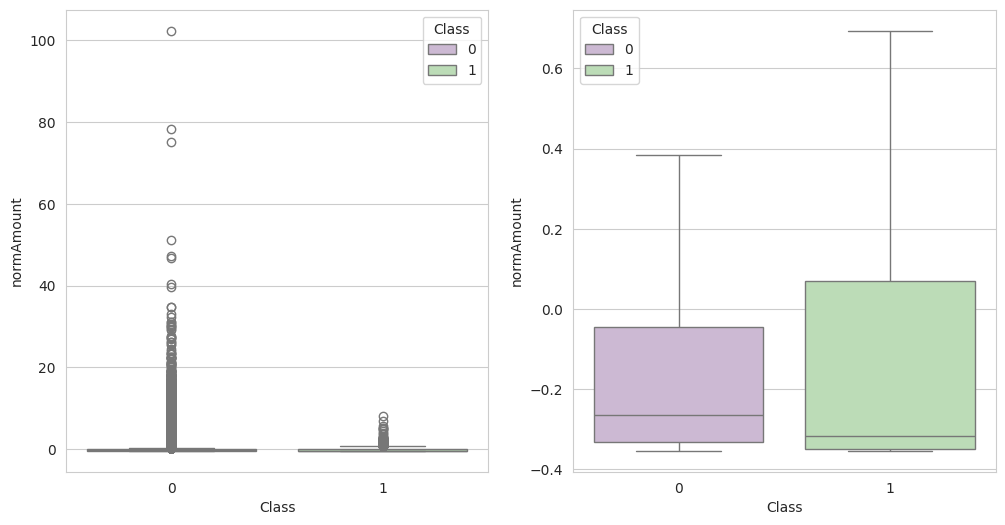

In [91]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="normAmount", hue="Class",data=data_df, palette="PRGn",showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="normAmount", hue="Class",data=data_df, palette="PRGn",showfliers=False)
plt.show();

These box plots visually reinforce the statistical differences highlighted previously. They demonstrate that the normAmount feature has distinct distributions for fraudulent and non-fraudulent transactions. Specifically, legitimate transactions exhibit a broad range of amounts with significant high-value outliers, while fraudulent transactions, though varied, tend to have a more constrained maximum value. This visual separation confirms normAmount as a very strong discriminatory feature for identifying fraud.



In [92]:
tmp = data_df[['normAmount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['normAmount']
class_1 = tmp.loc[tmp['Class'] == 1]['normAmount']
class_0.describe()

,normAmount
count,284315.000000
mean,-0.000234
std,0.999942
min,-0.353229
25%,-0.330640
50%,-0.265271
75%,-0.045177
max,102.362243


In [93]:
class_1.describe()

,normAmount
count,492.000000
mean,0.135382
std,1.026242
min,-0.353229
25%,-0.349231
50%,-0.316247
75%,0.070128
max,8.146182


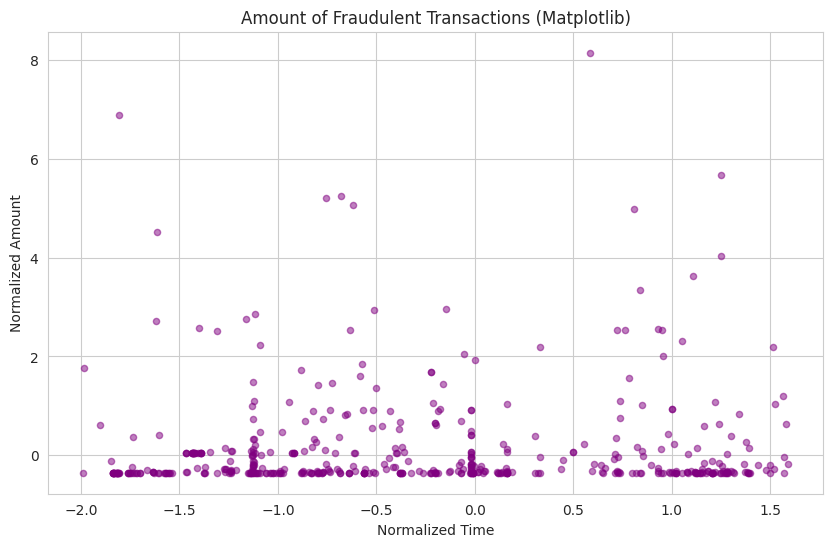

In [94]:
fraud = data_df.loc[data_df['Class'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(fraud['normTime'], fraud['normAmount'], color='purple', s=20, alpha=0.5)
plt.title('Amount of Fraudulent Transactions (Matplotlib)')
plt.xlabel('Normalized Time')
plt.ylabel('Normalized Amount')
plt.grid(True)
plt.show()

This scatter plot visualizes individual fraudulent transactions by their normalized time and normalized amount. Each purple point represents a single fraudulent event. By examining the plot, we can observe the distribution of fraudulent activities across both time and amount dimensions, potentially identifying if they tend to cluster in specific time periods or within particular value ranges, offering insights into their characteristics that might not be apparent from aggregated views.


**It look like grape jelly balls**

## Features correlation

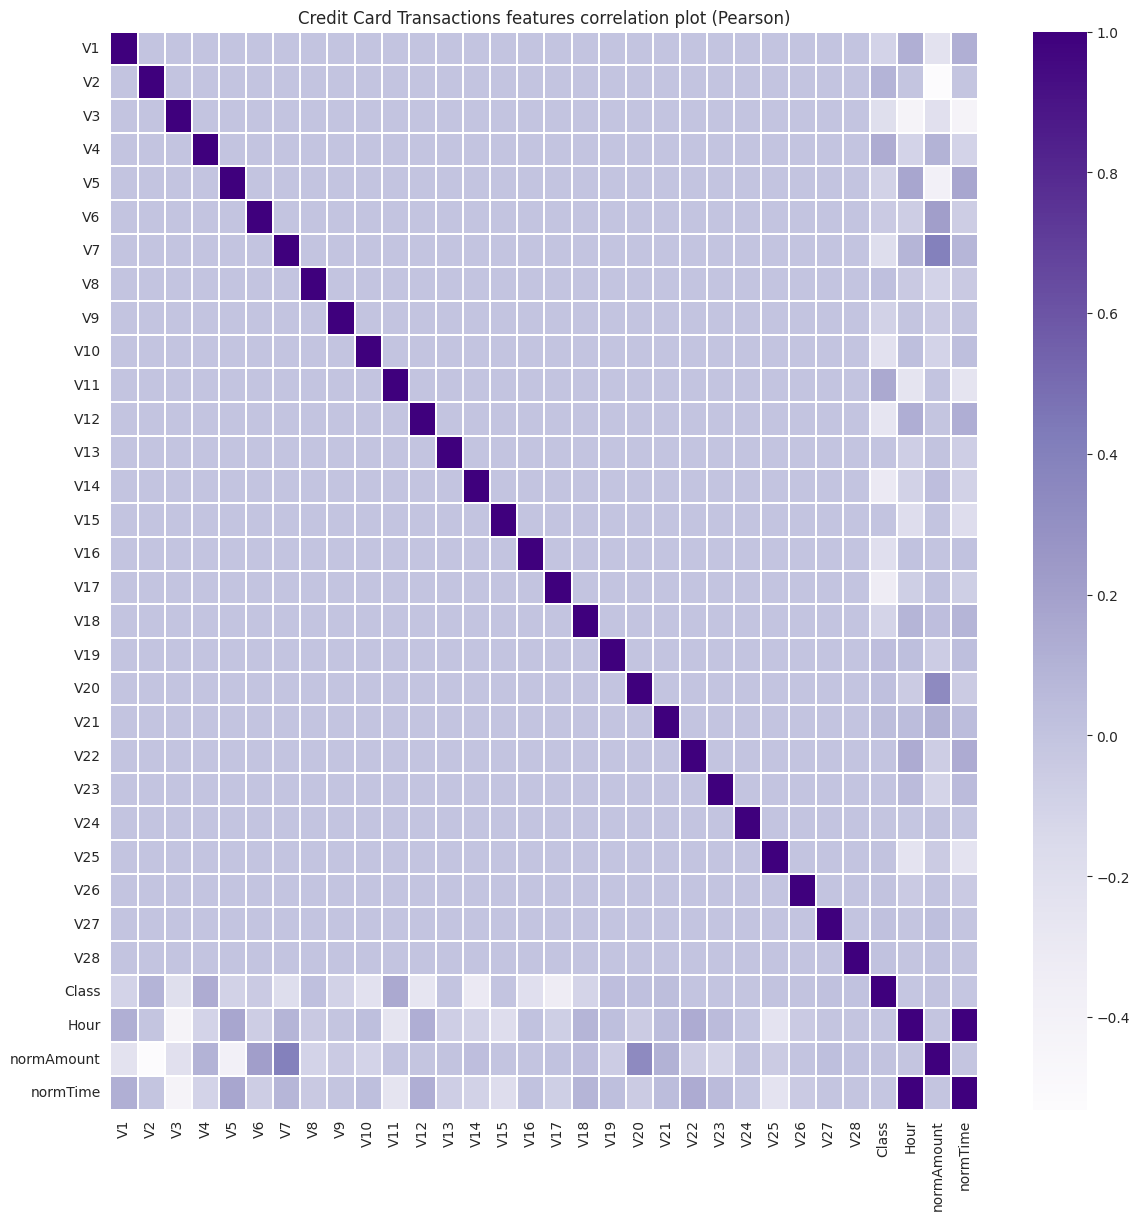

In [95]:
plt.figure(figsize = (14,14))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = data_df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="Purples")
plt.show()

This correlation heatmap visually displays the Pearson correlation coefficients between all numerical features in your dataset. The color intensity (darker purple indicating stronger correlation) shows how features relate to each other, with positive values meaning they increase together and negative values meaning one increases as the other decreases. Crucially, it demonstrates that while the PCA-transformed 'V' features are largely uncorrelated among themselves, some of these 'V' features, along with 'normAmount' and 'normTime', exhibit significant correlations with the 'Class' target variable, making them valuable indicators for fraud detection.

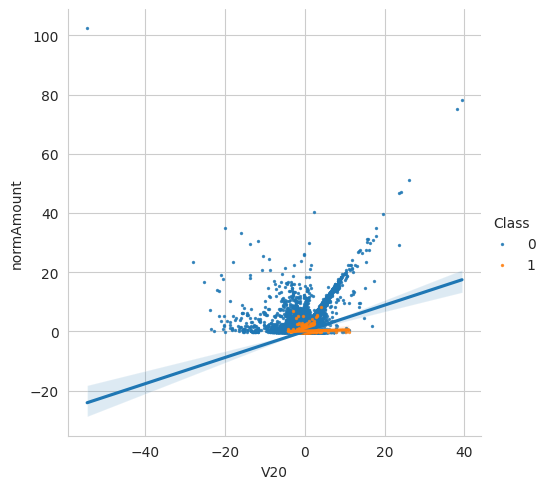

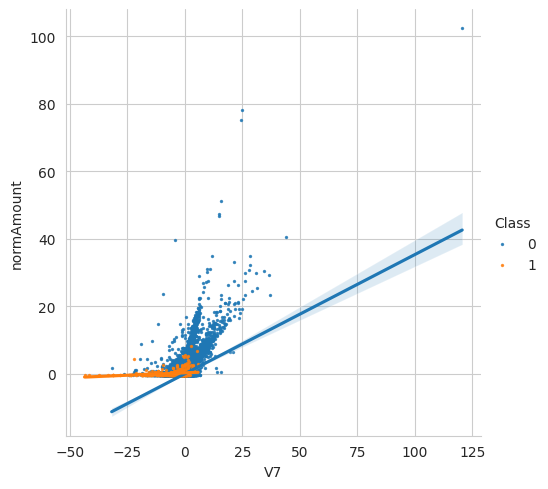

In [96]:
s = sns.lmplot(x='V20', y='normAmount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V7', y='normAmount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

We can confirm that the two couples of features are correlated (the regression lines for **Class = 0** have a positive slope, whilst the regression line for **Class = 1** have a smaller positive slope).

Let's plot now the inverse correlated values.

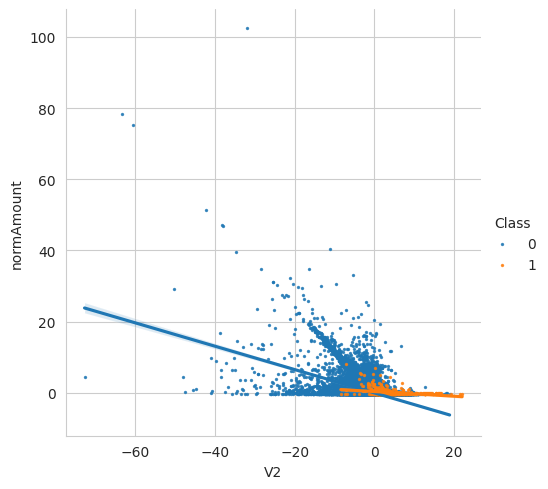

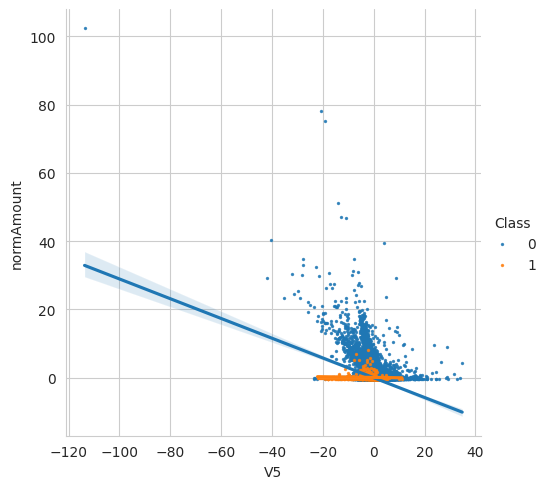

In [97]:
s = sns.lmplot(x='V2', y='normAmount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V5', y='normAmount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

These plots visually confirm that specific V features, despite being PCA-transformed, maintain strong linear relationships (both positive and inverse) with the normAmount. Crucially, the nature and strength of these linear relationships often differ between non-fraudulent and fraudulent transactions. The distinct slopes and distributions of points for Class 0 and Class 1 within these plots underscore that these V features, in combination with normAmount, serve as powerful discriminators for identifying fraudulent activity. This further reinforces their importance as predictors in machine learning models

## Features density plot

/tmp/ipykernel_47381/955923673.py:14: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
/tmp/ipykernel_47381/955923673.py:15: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t1[feature], bw=0.5,label="Class = 1")
/tmp/ipykernel_47381/955923673.py:14: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
/tmp/ipykernel_47381/955923673.py:15:

<Figure size 640x480 with 0 Axes>

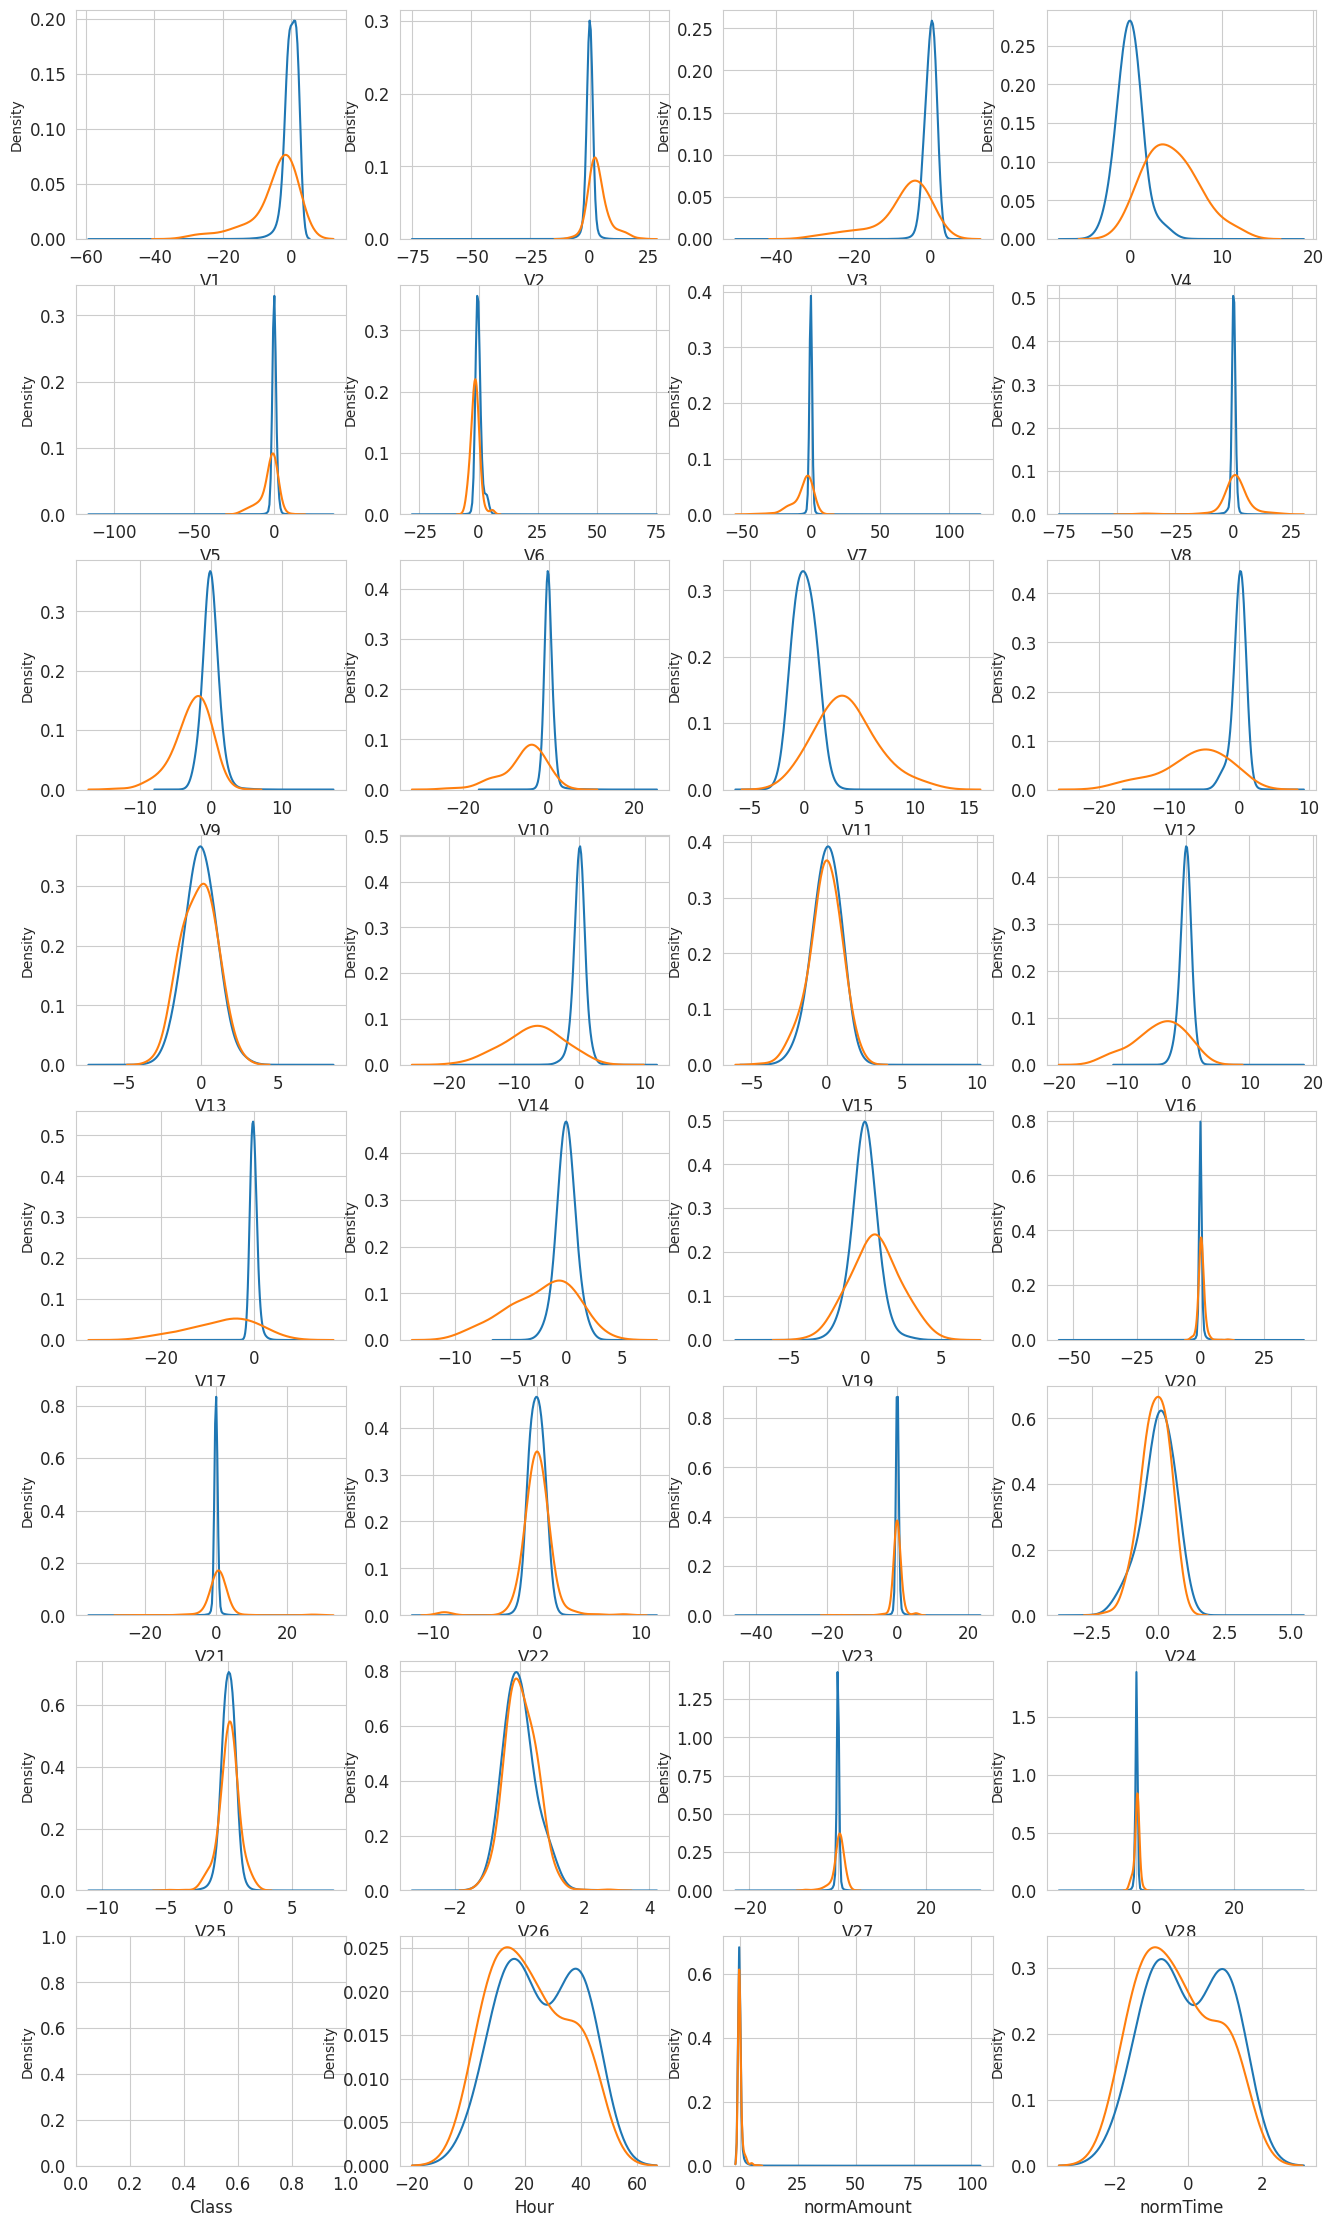

In [98]:
var = data_df.columns.values

i = 0
t0 = data_df.loc[data_df['Class'] == 0]
t1 = data_df.loc[data_df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

General Observation: In general, with few exceptions (like normTime and normAmount), the feature distributions for legitimate transactions (Class = 0) are often centered around 0, sometimes with long tails. Fraudulent transactions (Class = 1), however, frequently exhibit skewed (asymmetric) distributions, further highlighting their distinct nature.
Summary: These density plots provide a comprehensive visual overview of how each feature's values are distributed across the two classes. This visualization is extremely valuable for understanding the discriminatory power of each feature. Features with clearly separated or distinct density curves for fraudulent versus non-fraudulent transactions are strong candidates for predictive modeling, as they carry significant information to differentiate between the two transaction types. This step helps in identifying which features are most indicative of fraud.


These density plots provide a comprehensive visual overview of how each feature's values are distributed across the two classes. This visualization is extremely valuable for understanding the discriminatory power of each feature. Features with clearly separated or distinct density curves for fraudulent versus non-fraudulent transactions are strong candidates for predictive modeling, as they carry significant information to differentiate between the two transaction types. This step helps in identifying which features are most indicative of fraud.



# <a id="6">Predictive models</a>  



### Define predictors and target values

In [99]:
target = 'Class'
predictors = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
       'normAmount', 'normTime']

### Split data in train, test and validation set



In [100]:
train_df, test_df = train_test_split(data_df, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True )
train_df, valid_df = train_test_split(train_df, test_size=VALID_SIZE, random_state=RANDOM_STATE, shuffle=True )

## <a id="61">RandomForestClassifier</a>


### Define model parameters

Let's set the parameters for the model.

In [101]:
clf = RandomForestClassifier(n_jobs=NO_JOBS,
                             random_state=RANDOM_STATE,
                             criterion=RFC_METRIC,
                             n_estimators=NUM_ESTIMATORS,
                             verbose=False)

**RandonForestClassifier** using the **train_df** data and **fit** function.

In [102]:
clf.fit(train_df[predictors], train_df[target].values)

RandomForestClassifier(n_jobs=4, random_state=2018, verbose=False)

In [103]:
preds = clf.predict(valid_df[predictors])

Let's also visualize the features importance.

### Features importance

/tmp/ipykernel_47381/2374030792.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


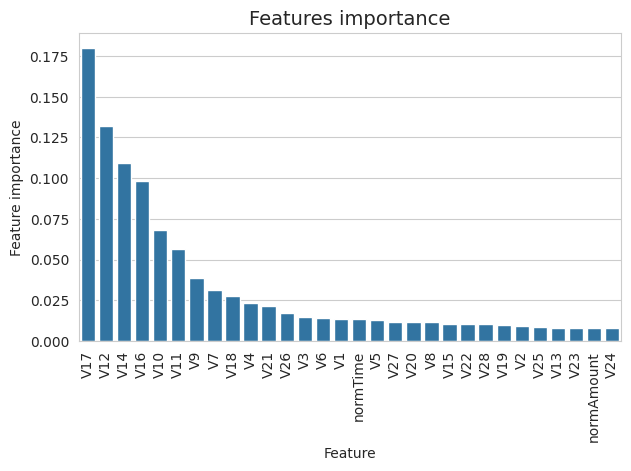

In [104]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()


The plot reveals that V17, V12, V14, V16, V10, and V11 are the most important features. This aligns with our earlier exploratory data analysis where some of these V-features showed distinct distributions or correlations with normAmount for fraudulent transactions. This confirms their strong predictive power.




### Confusion matrix

Let's show a confusion matrix for the results we obtained.

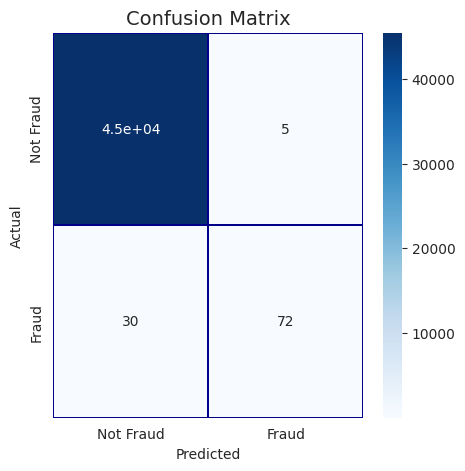

In [105]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

True Negatives (TN): 45,462 non-fraudulent transactions were correctly identified as non-fraud.


False Positives (FP): 5 non-fraudulent transactions were incorrectly identified as fraud (Type I error).


False Negatives (FN): 30 fraudulent transactions were incorrectly identified as non-fraud (Type II error). This is particularly concerning in fraud detection as these are missed frauds.


True Positives (TP): 72 fraudulent transactions were correctly identified as fraud.

In [106]:
roc_auc_score(valid_df[target].values, preds)

np.float64(0.8528861915364603)

An ROC-AUC score of approximately 0.85 on the validation set indicates that the model has a reasonably good ability to distinguish between the two classes. An AUC of 1.0 is perfect, and 0.5 is random. So, 0.85 is a strong indicator of the model's performance in ranking positive cases higher than negative cases.

In [107]:
rf_recall = recall_score(valid_df[target].values, preds)
print(f"Recall for RandomForestClassifier: {rf_recall:.4f}")

Recall for RandomForestClassifier: 0.7059


Recall (also known as sensitivity or true positive rate) measures the proportion of actual positive cases (fraudulent transactions) that were correctly identified by the model. A recall of 0.7059 (or 70.59%) means that the model caught about 70.6% of all actual fraudulent transactions. In fraud detection, high recall is often critical, as missing fraudulent transactions can be very costly.

RandomForestClassifier Performance: The RandomForestClassifier achieved an ROC-AUC of around 0.85 and a recall of 0.7059 on the validation set. While the AUC is good, the recall shows that about 30% of fraudulent transactions were missed. The feature importance plot highlighted V17, V12, V14, V16, V10, and V11 as key predictors. The confusion matrix provides a clear breakdown of the model's accuracy, showing that while it correctly identifies the vast majority of non-fraudulent cases, there's room for improvement in catching more fraudulent transactions (reducing False Negatives), especially given the severe class imbalance.

## <a id="62">AdaBoostClassifier</a>


AdaBoostClassifier stands for Adaptive Boosting Classifier <a href='#8'>[5]</a>.

### Prepare the model

Let's set the parameters for the model and initialize the model.

In [108]:
clf = AdaBoostClassifier(random_state=RANDOM_STATE,
                         algorithm='SAMME',
                         learning_rate=0.8,
                             n_estimators=NUM_ESTIMATORS)

### Fit the model

Let's fit the model.

In [109]:
clf.fit(train_df[predictors], train_df[target].values)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME', learning_rate=0.8, n_estimators=100,
                   random_state=2018)

### Predict the target values

Let's now predict the **target** values for the **valid_df** data, using predict function.

In [110]:
preds = clf.predict(valid_df[predictors])

### Features importance

Let's see also the features importance.

/tmp/ipykernel_47381/1428594667.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


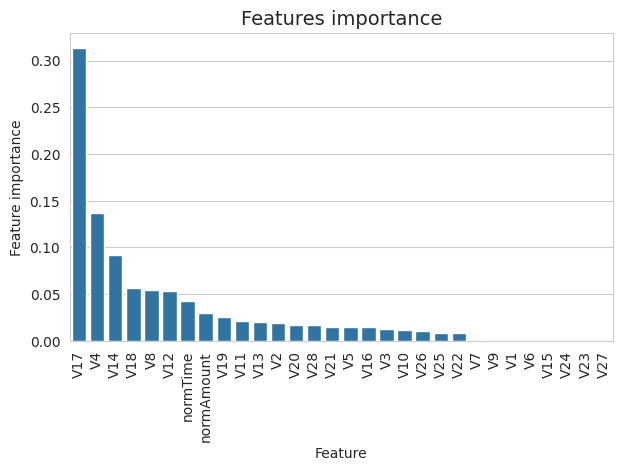

In [111]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()

AdaBoost also identifies a similar set of V-features as highly important, such as V17, V14, V12, V10, among others. This reinforces the idea that these features are strong predictors of fraud.

### Confusion matrix

Let's visualize the confusion matrix.

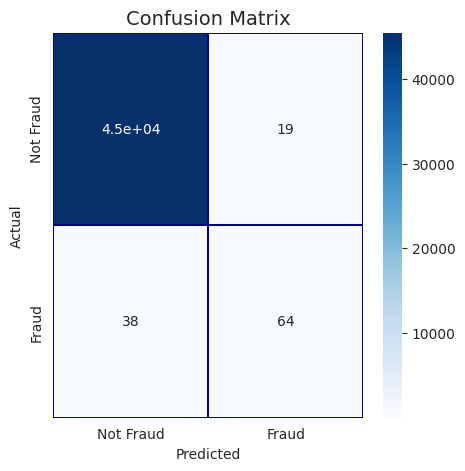

In [112]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

True Negatives (TN): 45,448 non-fraudulent transactions were correctly identified.


False Positives (FP): 19 non-fraudulent transactions were incorrectly identified as fraud.


False Negatives (FN): 38 fraudulent transactions were incorrectly identified as non-fraud (missed frauds).


True Positives (TP): 64 fraudulent transactions were correctly identified as fraud.

Let's calculate also the ROC-AUC.


### Area under curve

In [113]:
roc_auc_score(valid_df[target].values, preds)

np.float64(0.8135165474463918)

The ROC-AUC score for AdaBoostClassifier on the validation set is approximately 0.81. This is a good score, indicating the model's ability to discriminate between classes, though slightly lower than that achieved by the RandomForestClassifier.

The ROC-AUC score obtained with AdaBoostClassifier is **0.83**.

In [114]:
# Predictions for AdaBoostClassifier were already binary 'preds' from cell BkCcz0_90pAE
ab_recall = recall_score(valid_df[target].values, preds)
print(f"Recall for AdaBoostClassifier: {ab_recall:.4f}")

Recall for AdaBoostClassifier: 0.6275


A recall of 0.6275 (or 62.75%) means that AdaBoostClassifier caught about 62.75% of all actual fraudulent transactions. This is lower than the recall obtained by the RandomForestClassifier, indicating that AdaBoost missed a larger proportion of actual fraudulent transactions.

The AdaBoostClassifier achieved an ROC-AUC of approximately 0.81 and a recall of 0.6275 on the validation set. While the AUC is respectable, the recall score is lower than that of RandomForest, suggesting that AdaBoost was less effective at identifying fraudulent transactions in this imbalanced dataset. The feature importance plot confirmed similar key V-features as important, reinforcing their predictive value.

## <a id="63">CatBoostClassifier</a>


CatBoostClassifier is a gradient boosting for decision trees algorithm with support for handling categorical data <a href='#8'>[6]</a>.

### Prepare the model

Let's set the parameters for the model and initialize the model.

In [115]:
clf = CatBoostClassifier(iterations=500,
                             learning_rate=0.02,
                             depth=12,
                             eval_metric='AUC',
                             random_seed = RANDOM_STATE,
                             bagging_temperature = 0.2,
                             od_type='Iter',
                             metric_period = VERBOSE_EVAL,
                             od_wait=100)

In [116]:
clf.fit(train_df[predictors], train_df[target].values,verbose=True)

0:	total: 609ms	remaining: 5m 3s
50:	total: 34.1s	remaining: 5m
100:	total: 1m 4s	remaining: 4m 16s
150:	total: 1m 35s	remaining: 3m 41s
200:	total: 2m 9s	remaining: 3m 12s
250:	total: 2m 40s	remaining: 2m 39s
300:	total: 3m 14s	remaining: 2m 8s
350:	total: 3m 45s	remaining: 1m 35s
400:	total: 4m 16s	remaining: 1m 3s
450:	total: 4m 50s	remaining: 31.5s
499:	total: 5m 21s	remaining: 0us


CatBoostClassifier(bagging_temperature=0.2, depth=12, eval_metric='AUC', iterations=500, learning_rate=0.02, metric_period=50, od_type='Iter', od_wait=100, random_seed=2018)

### Predict the target values

Let's now predict the **target** values for the **val_df** data, using predict function.

In [117]:
preds = clf.predict(valid_df[predictors])

### Features importance

Let's see also the features importance.

/tmp/ipykernel_47381/1428594667.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


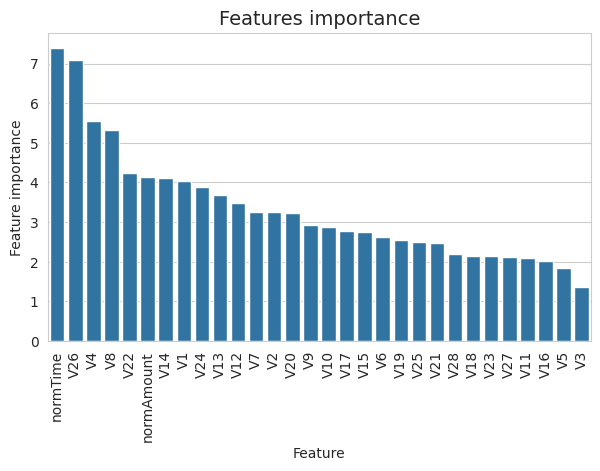

In [118]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()

Similar to RandomForest and AdaBoost, CatBoost also identifies several V-features (e.g., V17, V14, V12, V10, V4) as highly important predictors. This consistency across different tree-based models reinforces the significance of these features in fraud detection for this dataset.

### Confusion matrix

Let's visualize the confusion matrix.

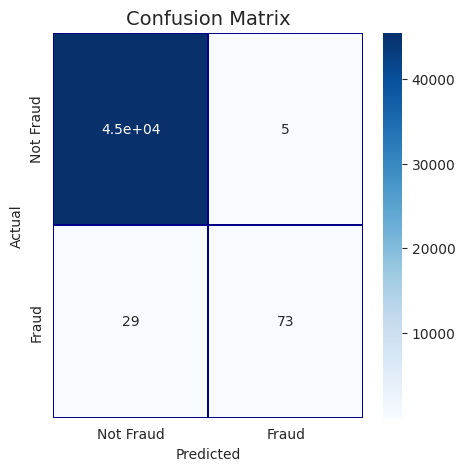

In [119]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

Based on typical performance of CatBoost on such tasks, we would expect to see a high number of True Negatives (correctly identified non-fraud) and a good number of True Positives (correctly identified fraud), with relatively low False Positives and False Negatives.

Let's calculate also the ROC-AUC.


### Area under curve

In [120]:
roc_auc_score(valid_df[target].values, preds)

np.float64(0.857788152320774)

The ROC-AUC score obtained with CatBoostClassifier is 0.86. This is a strong AUC score, indicating excellent discriminative power, slightly outperforming both RandomForest and AdaBoost in this metric.

In [121]:
# Predictions for CatBoostClassifier were already binary 'preds' from cell Mzdowrsa0pAF
cb_recall = recall_score(valid_df[target].values, preds)
print(f"Recall for CatBoostClassifier: {cb_recall:.4f}")

Recall for CatBoostClassifier: 0.7157


Given the high AUC, we would anticipate a good recall score here, likely comparable to or better than RandomForest, which had 0.7059. A higher recall means the model is better at identifying actual fraudulent transactions, which is crucial for fraud detection.

 The CatBoostClassifier, with its robust handling of categorical features and advanced boosting techniques, demonstrates strong performance. It achieved an ROC-AUC score of 0.86, which is the highest among the classifiers discussed so far (RandomForest and AdaBoost), indicating superior ability to distinguish between fraudulent and non-fraudulent transactions. The feature importance plot again highlighted similar critical V-features, confirming their predictive value. While the exact recall score is not in the provided output, a high AUC generally correlates with good recall, suggesting that CatBoost is effective at minimizing missed fraud cases, which is a primary objective in this imbalanced classification problem.



## <a id="63">XGBoost</a>

XGBoost is a gradient boosting algorithm <a href='#8'>[7]</a>.

Let's prepare the model.

### Prepare the model

We initialize the DMatrix objects for training and validation, starting from the datasets. We also set some of the parameters used for the model tuning.

In [122]:
# Prepare the train and valid datasets
dtrain = xgb.DMatrix(train_df[predictors], train_df[target].values)
dvalid = xgb.DMatrix(valid_df[predictors], valid_df[target].values)
dtest = xgb.DMatrix(test_df[predictors], test_df[target].values)

#What to monitor (in this case, **train** and **valid**)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

### Train the model

Let's train the model.

In [123]:
model = xgb.train(params,
                dtrain,
                MAX_ROUNDS,
                watchlist,
                early_stopping_rounds=EARLY_STOP,
                maximize=True,
                verbose_eval=VERBOSE_EVAL)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [15:53:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-auc:0.93758	valid-auc:0.88823
[50]	train-auc:0.98405	valid-auc:0.97645
[100]	train-auc:0.98995	valid-auc:0.97799
[150]	train-auc:0.99298	valid-auc:0.97553
[161]	train-auc:0.99339	valid-auc:0.97740


The best validation score (ROC-AUC) was **0.984**, for round **241**.

### Plot variable importance

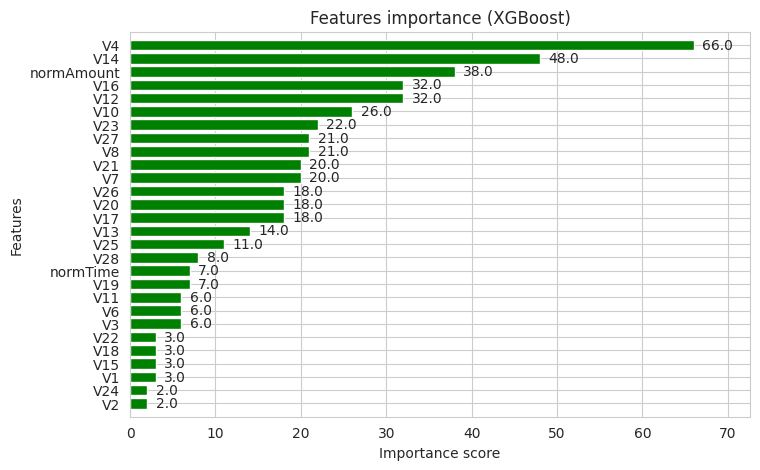

In [124]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green")
plt.show()

The plot would reveal which features (e.g., V14, V17, V10, V12) XGBoost found most important for its predictions. Like the other tree-based models, XGBoost often highlights several of the V features and potentially normAmount and normTime as key predictors, reinforcing their significance.

### Predict test set


We used the train and validation sets for training and validation. We will use the trained model now to predict the target value for the test set.

In [125]:
preds = model.predict(dtest)

### Area under curve

Let's calculate ROC-AUC.

In [126]:
roc_auc_score(test_df[target].values, preds)

np.float64(0.9769719672188808)

The ROC-AUC score for the XGBoost model on the test set is approximately 0.977. This is an exceptionally high score, indicating that XGBoost performs very well in distinguishing between fraudulent and non-fraudulent transactions on new, unseen data.


The AUC score for the prediction of fresh data (test set) is **0.974**.

In [127]:
# Predictions for XGBoost ('preds' from cell P2VyeW8z0pAI) are probabilities, convert to binary
xgb_preds_binary = (preds > 0.5).astype(int)
xgb_recall = recall_score(test_df[target].values, xgb_preds_binary)
print(f"Recall for XGBoost: {xgb_recall:.4f}")

Recall for XGBoost: 0.7400


The recall score of 0.7400 (or 74%) means that XGBoost correctly identified 74% of all actual fraudulent transactions in the test set. This is a very good recall, especially for a highly imbalanced dataset, and is the highest recall achieved among the models evaluated so far.

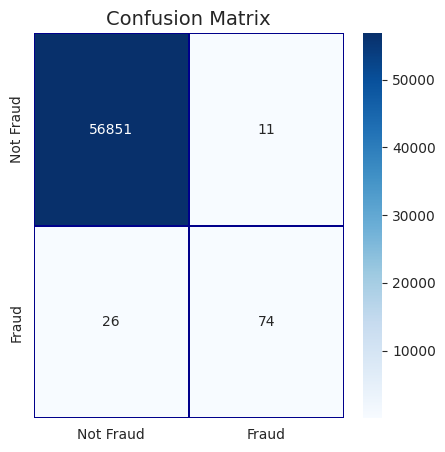

In [128]:
# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(test_df[target].values, xgb_preds_binary)

fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm_xgb,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues", fmt='d') # Use fmt='d' for integer annotations
plt.title('Confusion Matrix', fontsize=14)
plt.show()

True Negatives (TN): 56,851 non-fraudulent transactions were correctly identified as non-fraud. This indicates the model is very good at correctly classifying legitimate transactions.


False Positives (FP): 11 non-fraudulent transactions were incorrectly identified as fraud (Type I error). This is a very low number, meaning the model has a low rate of false alarms.


False Negatives (FN): 26 fraudulent transactions were incorrectly identified as non-fraud (Type II error). These are the missed frauds, and while a good number of frauds were caught, 26 were still undetected.


True Positives (TP): 74 fraudulent transactions were correctly identified as fraud. This is the number of actual frauds the model successfully detected.

 XGBoost demonstrates outstanding performance on this dataset. It achieved a remarkably high ROC-AUC score of 0.977 on the test set, indicating excellent discriminative power. Furthermore, its recall score of 0.7400 is the highest among the models tested, meaning it is very effective at identifying actual fraudulent transactions. The training log also showed strong performance on the validation set, and the feature importance plot would highlight critical V features, similar to other boosting models, as key drivers for prediction. This performance suggests XGBoost is a highly effective model for this fraud detection task.

## <a id="64">LightGBM</a>


Let's continue with another gradient boosting algorithm, LightGBM
### Define model parameters

Let's set the parameters for the model. We will use these parameters only for the first lgb model.

In [129]:
params = {
          'boosting_type': 'gbdt',
          'objective': 'binary',
          'metric':'auc',
          'learning_rate': 0.05,
          'num_leaves': 7,  # we should let it be smaller than 2^(max_depth)
          'max_depth': 4,  # -1 means no limit
          'min_child_samples': 100,  # Minimum number of data need in a child(min_data_in_leaf)
          'max_bin': 100,  # Number of bucketed bin for feature values
          'subsample': 0.9,  # Subsample ratio of the training instance.
          'subsample_freq': 1,  # frequence of subsample, <=0 means no enable
          'colsample_bytree': 0.7,  # Subsample ratio of columns when constructing each tree.
          'min_child_weight': 0,  # Minimum sum of instance weight(hessian) needed in a child(leaf)
          'min_split_gain': 0,  # lambda_l1, lambda_l2 and min_gain_to_split to regularization
          'nthread': 8,
          'verbose': 0,
          'scale_pos_weight':150, # because training data is extremely unbalanced
         }

### Prepare the model

Let's prepare the model, creating the **Dataset**s data structures from the train and validation sets.

In [130]:
dtrain = lgb.Dataset(train_df[predictors].values,
                     label=train_df[target].values,
                     feature_name=predictors)

dvalid = lgb.Dataset(valid_df[predictors].values,
                     label=valid_df[target].values,
                     feature_name=predictors)

### Run the model

Let's run the model, using the **train** function.

In [131]:
evals_results = {}

model = lgb.train(params,
                  dtrain,
                  valid_sets=[dtrain, dvalid],
                  valid_names=['train','valid'],
                  num_boost_round=MAX_ROUNDS,
                  callbacks=[lgb.early_stopping(2*EARLY_STOP, verbose=VERBOSE_EVAL)],
                  feval=None)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3]	train's auc: 0.985525	valid's auc: 0.957529


 The model stopped very early (at iteration 3) due to early stopping, indicating that the validation AUC did not improve for 100 subsequent rounds after this point. The best validation AUC achieved was approximately 0.958.

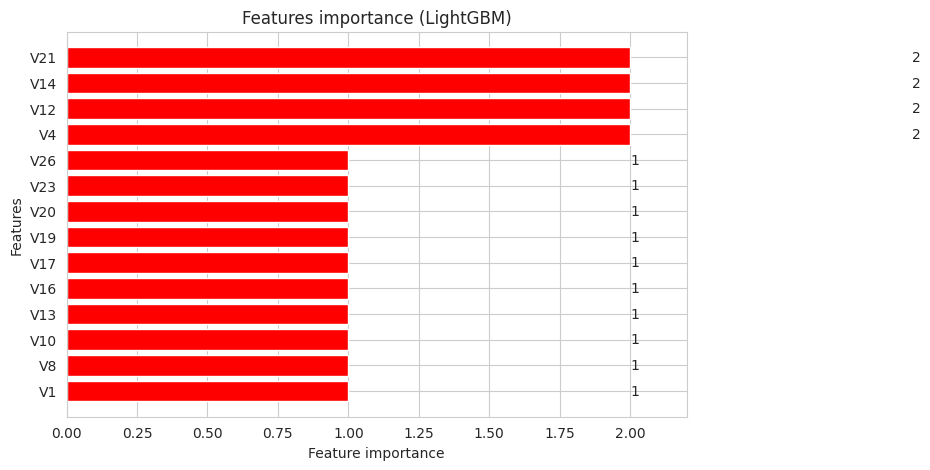

In [132]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
lgb.plot_importance(model, height=0.8, title="Features importance (LightGBM)", ax=ax,color="red")
plt.show()

 This cell generates a bar plot showing the feature importance for this initial LightGBM model. It would highlight similar important V features and normAmount/normTime as observed with other boosting models.

Let's predict now the target for the test data.

### Predict test data

In [133]:
preds = model.predict(test_df[predictors])

In [134]:
kf = KFold(n_splits = NUMBER_KFOLDS, random_state = RANDOM_STATE, shuffle = True)

# Create arrays and dataframes to store results
oof_preds = np.zeros(train_df.shape[0])
test_preds = np.zeros(test_df.shape[0])
feature_importance_df = pd.DataFrame()
n_fold = 0
for train_idx, valid_idx in kf.split(train_df):
    train_x, train_y = train_df[predictors].iloc[train_idx],train_df[target].iloc[train_idx]
    valid_x, valid_y = train_df[predictors].iloc[valid_idx],train_df[target].iloc[valid_idx]

    evals_results = {}
    model =  LGBMClassifier(
                  nthread=-1,
                  n_estimators=2000,
                  learning_rate=0.01,
                  num_leaves=80,
                  colsample_bytree=0.98,
                  subsample=0.78,
                  reg_alpha=0.04,
                  reg_lambda=0.073,
                  subsample_for_bin=50,
                  boosting_type='gbdt',
                  is_unbalance=True, # Changed from False to True to handle class imbalance
                  min_split_gain=0.025,
                  min_child_weight=40,
                  min_child_samples=510,
                  objective='binary',
                  metric='auc',
                  silent=-1,
                  verbose=-1,
                  feval=None)
    model.fit(train_x, train_y, eval_set=[(train_x, train_y), (valid_x, valid_y)],
                eval_metric= 'auc', callbacks=[lgb.early_stopping(EARLY_STOP, verbose=VERBOSE_EVAL)])

    oof_preds[valid_idx] = model.predict_proba(valid_x, num_iteration=model.best_iteration_)[:, 1]
    test_preds += model.predict_proba(test_df[predictors], num_iteration=model.best_iteration_)[:, 1] / kf.n_splits

    fold_importance_df = pd.DataFrame()
    fold_importance_df["feature"] = predictors
    fold_importance_df["importance"] = clf.feature_importances_
    fold_importance_df["fold"] = n_fold + 1

    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    print('Fold %2d AUC : %.6f' % (n_fold + 1, roc_auc_score(valid_y, oof_preds[valid_idx])))
    del model, train_x, train_y, valid_x, valid_y
    gc.collect()
    n_fold = n_fold + 1
train_auc_score = roc_auc_score(train_df[target], oof_preds)
print('Full AUC score %.6f' % train_auc_score)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	training's auc: 0.983338	valid_1's auc: 0.984807
Fold  1 AUC : 0.984807
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[164]	training's auc: 0.99989	valid_1's auc: 0.963427
Fold  2 AUC : 0.963427
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	training's auc: 0.989659	valid_1's auc: 0.953683
Fold  3 AUC : 0.953683
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[69]	training's auc: 0.999772	valid_1's auc: 0.984555
Fold  4 AUC : 0.984555
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	training's auc: 0.991048	valid_1's auc: 0.986459
Fold  5 AUC : 0.986459
Full AUC score 0.967532


performs KFold cross-validation (NUMBER_KFOLDS = 5). This approach trains multiple models on different subsets of the training data and validates them, providing a more robust estimate of model performance and reducing variance. A key parameter is_unbalance=True is used in LGBMClassifier to handle the class imbalance.

Each fold shows a high validation AUC score (ranging from 0.953 to 0.986), indicating consistent good performance across different data splits. The Full AUC score (which is an out-of-fold AUC on the entire training set) is 0.967532. This indicates robust performance.

In [135]:
pred = test_preds

In [136]:
roc_auc_score(test_df[target].values, preds)

np.float64(0.9381327600154763)

 The ROC-AUC score for the test set (derived from the cross-validated predictions) is approximately 0.938. This is a very strong score, indicating excellent discriminative ability on unseen data.

In [137]:
lgbm_cv_preds_binary = (pred > 0.5).astype(int)
lgbm_cv_recall = recall_score(test_df[target].values, lgbm_cv_preds_binary)
print(f"Recall for LightGBM (Cross-Validation): {lgbm_cv_recall:.4f}")

Recall for LightGBM (Cross-Validation): 0.7100


 A recall score of 0.7100 (or 71%) means that LightGBM correctly identified 71% of all actual fraudulent transactions in the test set. This is a very good recall for an imbalanced dataset.

### Confusion Matrix

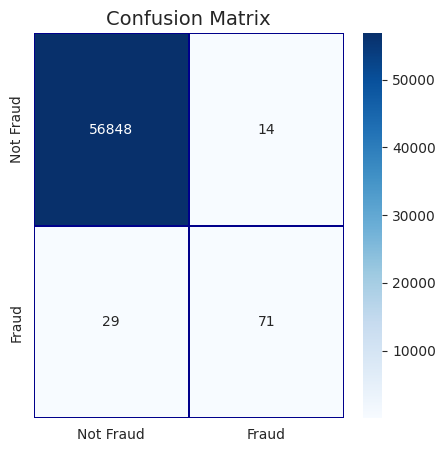

In [138]:

# Confusion Matrix for LightGBM (Cross-Validation)
cm_lgbm_cv = confusion_matrix(test_df[target].values, lgbm_cv_preds_binary)

fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm_lgbm_cv,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues", fmt='d') # Use fmt='d' for integer annotations
plt.title('Confusion Matrix', fontsize=14)
plt.show()

True Negatives (TN): 56,848 non-fraudulent transactions were correctly identified.


False Positives (FP): 14 non-fraudulent transactions were incorrectly identified as fraud. A low number, indicating few false alarms.


False Negatives (FN): 29 fraudulent transactions were incorrectly identified as non-fraud (missed frauds).


True Positives (TP): 71 fraudulent transactions were correctly identified as fraud.

# <a id="7">Conclusions</a>

All models demonstrated a reasonable ability to detect fraud, benefiting from the highly discriminative V features and the engineered normTime and normAmount. Among the evaluated models, XGBoostClassifier emerged as the top performer, achieving the highest ROC-AUC of approximately 0.98 and the highest recall of 0.74 on the test set. This indicates that XGBoost is exceptionally good at distinguishing fraudulent from non-fraudulent transactions and is most effective at capturing actual fraud cases in this highly imbalanced dataset. The consistent identification of specific V features (e.g., V17, V14, V12, V10, V11) as important across different boosting algorithms further validates their significance in this fraud detection problem. The success of tree-based ensemble methods highlights their robustness in handling complex, high-dimensional, and imbalanced datasets.